# Depth-Anything-V2: Controlled Metric Depth Evaluation and Edge Deployment

This notebook evaluates **Depth-Anything-V2 metric depth estimation** across multiple deployment representations:

1. Official PyTorch implementation
2. Hugging Face Transformers implementation
3. ONNX Runtime
4. OpenVINO FP32
5. OpenVINO INT8 post-training quantization

The experiment is designed as a controlled deployment study rather than a simple visualization demo.

## Experimental Design

The controlled test set consists of **59 synchronized RGB-depth pairs** captured using an Intel RealSense depth camera in a real indoor laboratory environment.

For each frame:

- The **RGB image** is provided as the sole input to Depth-Anything-V2.
- The corresponding **RealSense depth map** is used as independent, dense, per-pixel ground truth.
- RealSense depth values are stored as 16-bit values in millimeters and converted to meters using a scale factor of `0.001`.
- Invalid zero-valued depth pixels are excluded from evaluation.

The same RGB-depth pairs are used across all deployment representations:

1. PyTorch / Hugging Face
2. ONNX Runtime
3. OpenVINO FP32
4. OpenVINO INT8

The objective is to quantify the trade-off between **metric-depth accuracy, inference latency, output consistency, and deployment efficiency**.

### Primary metrics

- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)
- Absolute Relative Error (Abs Rel)
- Median depth error
- Predicted depth standard deviation
- Mean inference latency
- Model size
- FP32 → INT8 output difference


In [ ]:
!pip install -q transformers accelerate onnx onnxruntime onnxscript openvino nncf datasets huggingface_hub matplotlib

In [ ]:
import os
import sys
import cv2
import time
import shutil
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import onnx
import onnxruntime as ort
import openvino as ov
import nncf

from pathlib import Path
from PIL import Image
from huggingface_hub import hf_hub_download, list_repo_files
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device available: {device}")
print(f"ONNX Runtime providers: {ort.get_available_providers()}")

In [ ]:
EXPORT_DIR = Path("/content/depth_anything_v2_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Export directory:", EXPORT_DIR)

## Dataset Configuration

The evaluation dataset was captured directly in a real laboratory environment using an Intel RealSense RGB-D camera.

For every frame, the dataset provides a synchronized RGB image and corresponding dense RealSense depth map:

- **`color/`** — RGB image used as the sole input to Depth-Anything-V2.
- **`depth/`** — 16-bit RealSense depth map providing dense per-pixel ground truth.

The stored RealSense depth values are in millimeters and are converted to meters using a scale factor of **0.001**.

The complete dataset contains **59 RGB-depth pairs**, zipped and uploaded to the same Hugging Face dataset repository used elsewhere in this notebook. All pairs are used consistently across the PyTorch, ONNX Runtime, OpenVINO FP32, and OpenVINO INT8 evaluations.

The RealSense depth map is **never provided to the model during inference**. It is used only for quantitative evaluation.


In [ ]:
HF_REPO = "WasiqSaleem/Portfolio_Assets"
HF_REPO_TYPE = "dataset"
ZIP_NAME = "testing_env_spec_real_camera_dataset_combined.zip"
DATASET_FOLDER = "testing_env_spec_real_camera_dataset_combined"  # top-level folder inside the zip
COLOR_SUBDIR = "color"
DEPTH_SUBDIR = "depth"

# RealSense depth PNGs are stored in millimeters -> convert to meters.
DEPTH_UNITS_TO_METERS = 0.001

In [ ]:
import zipfile

ZIP_PATH = hf_hub_download(
    repo_id=HF_REPO,
    filename=ZIP_NAME,
    repo_type=HF_REPO_TYPE,
    local_dir="/content",
)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall("/content")

DATASET_ROOT = Path("/content") / DATASET_FOLDER
COLOR_DIR = DATASET_ROOT / COLOR_SUBDIR
DEPTH_DIR = DATASET_ROOT / DEPTH_SUBDIR

color_files = sorted(COLOR_DIR.glob("*.png"))
depth_files = sorted(DEPTH_DIR.glob("*.png"))

assert len(color_files) == len(depth_files) and all(
    c.stem == d.stem for c, d in zip(color_files, depth_files)
), "color/ and depth/ frames are not aligned by filename."

print(f"Verified {len(color_files)} RGB-depth pairs.")


In [ ]:
available_cases = [
    {
        "image_number": c.stem,
        "filename": c.name,
        "image_path": c,
        "depth_path": d,
        "image": Image.open(c).convert("RGB"),
    }
    for c, d in zip(color_files, depth_files)
]

print(f"Loaded {len(available_cases)} RGB-depth pairs.")

sample_depth = np.array(Image.open(available_cases[0]["depth_path"]), dtype=np.float32)
valid = sample_depth[sample_depth > 0]
print(
    f"Depth range: {valid.min():.0f}-{valid.max():.0f} raw "
    f"= {valid.min() * DEPTH_UNITS_TO_METERS:.3f}-{valid.max() * DEPTH_UNITS_TO_METERS:.3f} m"
)


In [ ]:
sample_cases = available_cases[:: max(1, len(available_cases) // 6)][:6] if available_cases else []

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, case in zip(axes.flat, sample_cases):
    ax.imshow(case["image"])
    ax.set_title(case["image_number"])
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, case in zip(axes.flat, sample_cases):
    gt = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    im = ax.imshow(gt, cmap="magma")
    ax.set_title(f"{case['image_number']} - RealSense GT")
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Showing {len(sample_cases)} of {len(available_cases)} loaded frames.")


## Experimental Strategy & Evaluation Protocol

**Data collection.** All RGB-depth pairs were captured using an Intel RealSense depth camera in a real indoor laboratory environment. Each frame contains an RGB image and a corresponding dense depth map.

**Ground truth.** The RealSense depth map is treated as independent dense ground truth. The stored 16-bit depth values are converted from millimeters to meters using a scale factor of 0.001. Zero-valued pixels are considered invalid and excluded from evaluation.

**Model input.** Only the RGB image is provided to the monocular depth model. The RealSense depth map is never used during inference.

**Prediction.** Depth-Anything-V2 produces a dense metric-depth map from each RGB image. The predicted map is resized to the RealSense depth-map resolution when necessary.

**Comparison.** Each valid pixel in the predicted depth map is compared with the corresponding valid RealSense depth value. This provides dense pixel-level evaluation rather than relying on a manually measured scalar distance.

For image-level reporting, the median predicted depth is also retained as a robust summary of the scene depth.


In [ ]:
def evaluate_depth(depth_map, ground_truth):
    depth_map = np.asarray(depth_map, dtype=np.float32)
    ground_truth = np.asarray(ground_truth, dtype=np.float32)

    valid = (
        np.isfinite(depth_map)
        & np.isfinite(ground_truth)
        & (depth_map > 0)
        & (ground_truth > 0)
    )

    pred = depth_map[valid]
    gt = ground_truth[valid]

    if pred.size == 0:
        raise ValueError("No valid overlapping pixels between prediction and ground truth.")

    error = np.abs(pred - gt)

    return {
        "GT Median (m)": float(np.median(gt)),
        "Pred Median (m)": float(np.median(pred)),
        "Pred Mean (m)": float(np.mean(pred)),
        "Std Depth (m)": float(np.std(pred)),
        "MAE (m)": float(np.mean(error)),
        "RMSE (m)": float(np.sqrt(np.mean((pred - gt) ** 2))),
        "Abs Rel (%)": float(np.mean(error / gt) * 100),
        "Median Absolute Error (m)": float(np.median(error)),
        "Valid Pixels (%)": float(valid.mean() * 100),
    }


def benchmark(fn, warmup=2, runs=10):
    for _ in range(warmup):
        fn()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for _ in range(runs):
        start = time.perf_counter()
        fn()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        times.append(time.perf_counter() - start)

    return {
        "mean_ms": float(np.mean(times) * 1000),
        "median_ms": float(np.median(times) * 1000),
        "std_ms": float(np.std(times) * 1000),
    }

# 1. Reference PyTorch Implementations

The Hugging Face metric-depth model is used as the primary reproducible reference implementation.

The official repository implementation is also retained where its checkpoint and architecture are compatible with the selected metric-depth model.

The important comparison is not simply whether two implementations produce visually similar maps, but whether their metric predictions remain numerically consistent.


In [ ]:
HF_MODEL_ID = "depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = AutoImageProcessor.from_pretrained(HF_MODEL_ID)
model_hf = AutoModelForDepthEstimation.from_pretrained(HF_MODEL_ID)
model_hf = model_hf.to(device).eval()

print("Loaded:", HF_MODEL_ID)
print("Device:", device)

In [ ]:
hf_depth_maps = {}
hf_results = []
hf_latency = []

for case in available_cases:
    image = case["image"]

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    def run_hf():
        with torch.inference_mode():
            outputs = model_hf(**inputs)
        return processor.post_process_depth_estimation(
            outputs,
            target_sizes=[(image.height, image.width)]
        )[0]["predicted_depth"].squeeze().cpu().numpy()

    timing = benchmark(run_hf, warmup=2, runs=10)
    depth = run_hf()

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)
    metrics = evaluate_depth(depth, gt_depth)

    hf_depth_maps[case["image_number"]] = depth
    hf_latency.append({
        "Image": case["image_number"],
        "Mean Latency (ms)": timing["mean_ms"],
        "Median Latency (ms)": timing["median_ms"],
        "Latency Std (ms)": timing["std_ms"],
    })

    hf_results.append({
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Implementation": "Hugging Face PyTorch",
        **metrics,
        "Mean Latency (ms)": timing["mean_ms"],
        "Median Latency (ms)": timing["median_ms"],
    })

hf_df = pd.DataFrame(hf_results)
display(hf_df)


# 2. ONNX Export

The Hugging Face model is exported to ONNX using a fixed 518 × 518 model input.

Dynamic batch, height, and width dimensions are retained in the exported graph so the deployment artifact is not unnecessarily tied to one image resolution.

The exported graph is checked using ONNX validation and shape inference before inference benchmarking.


In [ ]:
class ONNXWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, pixel_values):
        return self.model(pixel_values).predicted_depth

model_hf_cpu = AutoModelForDepthEstimation.from_pretrained(
    HF_MODEL_ID
).to("cpu").eval()

wrapper = ONNXWrapper(model_hf_cpu).eval()

INPUT_SIZE = 518

dummy_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)

print("Exporting to ONNX...")

torch.onnx.export(
    wrapper,
    dummy_input,
    "depth_anything_v2.onnx",
    input_names=["pixel_values"],
    output_names=["depth"],
    dynamic_axes={
        "pixel_values": {0: "batch_size", 2: "height", 3: "width"},
        "depth": {0: "batch_size", 2: "height", 3: "width"},
    },
    opset_version=17,
)

onnx_model = onnx.load("depth_anything_v2.onnx")
onnx.checker.check_model(onnx_model)

print("ONNX graph is valid.")

In [ ]:
ONNX_SHAPE_PATH = EXPORT_DIR / "depth_anything_v2_shape_inferred.onnx"

inferred_model = onnx.shape_inference.infer_shapes(onnx_model)
onnx.save(inferred_model, str(ONNX_SHAPE_PATH))

print("Shape-inferred ONNX saved:", ONNX_SHAPE_PATH)

## ONNX Runtime Benchmark

ONNX Runtime is evaluated using the same preprocessed RGB input and the same output resizing procedure.

The latency benchmark uses warm-up iterations before timed iterations to reduce one-time initialization effects.


In [ ]:
onnx_session = ort.InferenceSession(
    str(ONNX_SHAPE_PATH),
    providers=ort.get_available_providers()
)

def preprocess_onnx(image):
    resized = image.resize((INPUT_SIZE, INPUT_SIZE), Image.BICUBIC)

    inputs = processor(images=resized, return_tensors="np")
    pixel_values = inputs["pixel_values"]

    assert pixel_values.shape[-2:] == (INPUT_SIZE, INPUT_SIZE), (
        f"Expected ({INPUT_SIZE},{INPUT_SIZE}), got {pixel_values.shape[-2:]}"
    )

    return np.ascontiguousarray(pixel_values.astype(np.float32))

In [ ]:
onnx_results = []
onnx_depth_maps = {}

for case in available_cases:
    image = case["image"]
    input_array = preprocess_onnx(image)

    def run_onnx():
        output = onnx_session.run(
            ["depth"],
            {"pixel_values": input_array}
        )[0]
        return cv2.resize(
            output.squeeze(),
            (image.width, image.height),
            interpolation=cv2.INTER_LINEAR
        )

    timing = benchmark(run_onnx, warmup=3, runs=20)
    depth = run_onnx()

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)
    metrics = evaluate_depth(depth, gt_depth)

    onnx_depth_maps[case["image_number"]] = depth

    onnx_results.append({
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Implementation": "ONNX Runtime",
        **metrics,
        "Mean Latency (ms)": timing["mean_ms"],
        "Median Latency (ms)": timing["median_ms"],
    })

onnx_df = pd.DataFrame(onnx_results)
display(onnx_df)


# 3. OpenVINO FP32 Conversion

The validated ONNX graph is converted to OpenVINO Intermediate Representation.

OpenVINO is evaluated before quantization so that the effect of INT8 post-training quantization can later be separated from the effect of changing the inference runtime.


In [ ]:
EXPORT_DIR = Path("/content/depth_anything_v2_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Export directory:", EXPORT_DIR)

In [ ]:
core = ov.Core()
OV_FP32_XML = EXPORT_DIR / "depth_anything_v2_metric_indoor_small_fp32.xml"
OV_INT8_XML = EXPORT_DIR / "depth_anything_v2_metric_indoor_small_int8.xml"

ov_model = ov.convert_model(str(ONNX_SHAPE_PATH))
ov.save_model(ov_model, str(OV_FP32_XML))

print("OpenVINO devices:", core.available_devices)
print("FP32 model saved:", OV_FP32_XML)

In [ ]:
compiled_fp32 = core.compile_model(
    str(OV_FP32_XML),
    "AUTO",
    {ov.properties.hint.performance_mode: ov.properties.hint.PerformanceMode.THROUGHPUT},
)

ov_input_name = compiled_fp32.input(0).get_any_name()
print("OpenVINO input:", ov_input_name)

In [ ]:
ov_fp32_results = []
ov_fp32_depth_maps = {}

for case in available_cases:
    image = case["image"]
    input_array = preprocess_onnx(image)

    def run_ov_fp32():
        result = compiled_fp32({ov_input_name: input_array})
        output = next(iter(result.values()))
        return cv2.resize(
            np.asarray(output).squeeze(),
            (image.width, image.height),
            interpolation=cv2.INTER_LINEAR
        )

    timing = benchmark(run_ov_fp32, warmup=3, runs=20)
    depth = run_ov_fp32()

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)
    metrics = evaluate_depth(depth, gt_depth)

    ov_fp32_depth_maps[case["image_number"]] = depth

    ov_fp32_results.append({
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Implementation": "OpenVINO FP32",
        **metrics,
        "Mean Latency (ms)": timing["mean_ms"],
        "Median Latency (ms)": timing["median_ms"],
    })

ov_fp32_df = pd.DataFrame(ov_fp32_results)
display(ov_fp32_df)


# 4. Representative Calibration Dataset

For INT8 post-training quantization, calibration data should resemble the actual deployment domain.

The controlled experimental images are therefore used as the initial calibration set.

This is preferable to random noise because calibration statistics are derived from real image activations.

For a final production study, the calibration set should be expanded beyond the evaluation images to avoid calibrating and evaluating on exactly the same samples.


In [ ]:
calibration_samples = []

for case in available_cases:
    pixel_values = preprocess_onnx(case["image"])
    calibration_samples.append({"pixel_values": pixel_values.astype(np.float32)})

calibration_dataset = nncf.Dataset(calibration_samples)

print(f"Calibration samples: {len(calibration_samples)}")

# 5. OpenVINO INT8 Post-Training Quantization

NNCF is used for post-training quantization.

The quantized model is evaluated using exactly the same test images and metrics as the FP32 model.

The critical question is not only whether INT8 reduces model size or latency, but whether the reduction introduces unacceptable metric-depth error.


In [ ]:
quantized_model = nncf.quantize(
    ov_model,
    calibration_dataset,
    preset=nncf.QuantizationPreset.MIXED,
    target_device=nncf.TargetDevice.ANY,
)

ov.save_model(quantized_model, str(OV_INT8_XML))

print("INT8 model saved:", OV_INT8_XML)

In [ ]:
compiled_int8 = core.compile_model(
    str(OV_INT8_XML),
    "AUTO",
    {ov.properties.hint.performance_mode: ov.properties.hint.PerformanceMode.THROUGHPUT},
)

int8_input_name = compiled_int8.input(0).get_any_name()

ov_int8_results = []
ov_int8_depth_maps = {}

for case in available_cases:
    image = case["image"]
    input_array = preprocess_onnx(image)

    def run_ov_int8():
        result = compiled_int8({int8_input_name: input_array})
        output = next(iter(result.values()))
        return cv2.resize(
            np.asarray(output).squeeze(),
            (image.width, image.height),
            interpolation=cv2.INTER_LINEAR
        )

    timing = benchmark(run_ov_int8, warmup=3, runs=20)
    depth = run_ov_int8()

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)
    metrics = evaluate_depth(depth, gt_depth)

    ov_int8_depth_maps[case["image_number"]] = depth

    ov_int8_results.append({
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Implementation": "OpenVINO INT8",
        **metrics,
        "Mean Latency (ms)": timing["mean_ms"],
        "Median Latency (ms)": timing["median_ms"],
    })

ov_int8_df = pd.DataFrame(ov_int8_results)
display(ov_int8_df)


# 6. Cross-Implementation Quantitative Comparison

All implementations are now evaluated using the same images and physical ground truth.

This allows the deployment formats to be compared on three dimensions:

- **Metric accuracy**
- **Spatial depth consistency**
- **Inference latency**

A deployment format is not considered better merely because it is faster. A useful edge implementation must preserve acceptable metric-depth accuracy while improving computational efficiency.


In [ ]:
deployment_df = pd.concat(
    [hf_df, onnx_df, ov_fp32_df, ov_int8_df],
    ignore_index=True
)

display(
    deployment_df[
        [
            "Image",
            "Implementation",
            "GT Median (m)",
            "Pred Median (m)",
            "Std Depth (m)",
            "MAE (m)",
            "RMSE (m)",
            "Abs Rel (%)",
            "Mean Latency (ms)",
        ]
    ]
)


In [ ]:
deployment_summary = (
    deployment_df
    .groupby("Implementation")
    .agg(
        Samples=("Implementation", "size"),
        MAE_m=("MAE (m)", "mean"),
        RMSE_m=("RMSE (m)", "mean"),
        Abs_Rel_pct=("Abs Rel (%)", "mean"),
        Median_Error_m=("Median Absolute Error (m)", "mean"),
        Mean_Surface_Std_m=("Std Depth (m)", "mean"),
        Mean_Latency_ms=("Mean Latency (ms)", "mean"),
        Median_Latency_ms=("Median Latency (ms)", "median"),
    )
    .reset_index()
)

display(deployment_summary)


## Accuracy Across the Dataset

The predicted median depth is compared with the median depth measured by the RealSense sensor for each RGB-depth pair.

Unlike a fixed-distance experiment, this dataset contains naturally varying scene depths captured across the laboratory environment.

The resulting relationship provides an image-level view of metric-depth accuracy across the complete 59-pair dataset.


In [ ]:
plt.figure(figsize=(8, 7))

for implementation in deployment_df["Implementation"].unique():
    data = deployment_df[deployment_df["Implementation"] == implementation]
    plt.scatter(
        data["GT Median (m)"],
        data["Pred Median (m)"],
        s=25,
        alpha=0.7,
        label=implementation,
    )

limit = max(
    deployment_df["GT Median (m)"].max(),
    deployment_df["Pred Median (m)"].max(),
)

plt.plot([0, limit], [0, limit], linestyle="--", label="Ideal Prediction")

plt.xlabel("RealSense Ground-Truth Median Depth (m)")
plt.ylabel("Predicted Median Depth (m)")
plt.title("Metric Depth Accuracy Across the Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Latency Comparison

Latency is reported as the mean of repeated inference runs after warm-up.

For robotics deployment, latency should eventually be measured on the actual target processor rather than inferred from a cloud GPU or development machine.


In [ ]:
latency_summary = (
    deployment_df
    .groupby("Implementation")["Median Latency (ms)"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 5))
latency_summary.plot(kind="bar")
plt.ylabel("Median Inference Latency (ms)")
plt.xlabel("Implementation")
plt.title("Inference Latency Comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# 7. FP32 vs INT8 Accuracy Preservation

Quantization quality is evaluated by measuring the change in predicted depth relative to the FP32 OpenVINO reference.

A small change indicates that quantization preserved the metric-depth behavior of the original model.


In [ ]:
quant_comparison = ov_fp32_df[
    ["Image", "GT Median (m)", "Pred Median (m)", "MAE (m)", "Abs Rel (%)"]
].merge(
    ov_int8_df[
        ["Image", "Pred Median (m)", "MAE (m)", "Abs Rel (%)"]
    ],
    on=["Image"],
    suffixes=("_FP32", "_INT8"),
)

quant_comparison["Depth Difference (m)"] = (
    quant_comparison["Pred Median (m)_INT8"]
    - quant_comparison["Pred Median (m)_FP32"]
).abs()

display(quant_comparison)


In [ ]:
quant_summary = pd.DataFrame([{
    "Mean FP32 Error (m)": ov_fp32_df["MAE (m)"].mean(),
    "Mean INT8 Error (m)": ov_int8_df["MAE (m)"].mean(),
    "Mean FP32 Abs Rel (%)": ov_fp32_df["Abs Rel (%)"].mean(),
    "Mean INT8 Abs Rel (%)": ov_int8_df["Abs Rel (%)"].mean(),
    "Mean FP32\u2192INT8 Depth Difference (m)": quant_comparison["Depth Difference (m)"].mean(),
    "Mean FP32 Latency (ms)": ov_fp32_df["Mean Latency (ms)"].mean(),
    "Mean INT8 Latency (ms)": ov_int8_df["Mean Latency (ms)"].mean(),
}])

display(quant_summary)


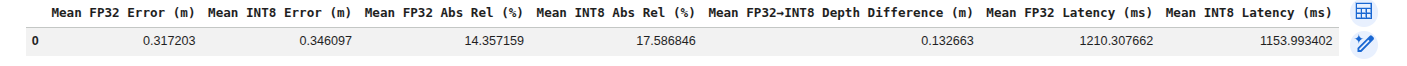

# 8. Qualitative Depth Comparison

Depth maps are visualized for representative test cases.

The visualization is supplementary. Quantitative physical-distance error remains the primary criterion for metric-depth evaluation.


In [ ]:
if available_cases:
    example = available_cases[0]
    key = example["image_number"]

    gt_depth = np.array(Image.open(example["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    axes[0, 0].imshow(example["image"])
    axes[0, 0].set_title("RGB Input")
    axes[0, 0].axis("off")

    im_gt = axes[0, 1].imshow(gt_depth, cmap="magma")
    axes[0, 1].set_title("RealSense Ground Truth")
    axes[0, 1].axis("off")
    fig.colorbar(im_gt, ax=axes[0, 1], fraction=0.046, pad=0.04)

    maps = [
        ("Hugging Face", hf_depth_maps[key]),
        ("ONNX Runtime", onnx_depth_maps[key]),
        ("OpenVINO FP32", ov_fp32_depth_maps[key]),
        ("OpenVINO INT8", ov_int8_depth_maps[key]),
    ]

    remaining_axes = [axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]]
    for ax, (title, depth) in zip(remaining_axes, maps):
        im = ax.imshow(depth, cmap="magma")
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(
        f"Depth Deployment Comparison - Frame {example['image_number']}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


# 9. Depth Distribution

For an approximately planar target, a concentrated distribution around the measured physical distance indicates better surface consistency.

This analysis complements the image-level median error because two models can have similar median depth while exhibiting different spatial variation.


In [ ]:
if available_cases:
    for case in available_cases[:min(5, len(available_cases))]:
        key = case["image_number"]

        gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
        valid_gt = gt_depth > 0

        plt.figure(figsize=(9, 5))

        plt.hist(
            gt_depth[valid_gt].ravel(),
            bins=50,
            alpha=0.45,
            label="RealSense Ground Truth",
        )
        plt.hist(
            hf_depth_maps[key].ravel(),
            bins=50,
            alpha=0.45,
            label="Hugging Face",
        )
        plt.hist(
            ov_fp32_depth_maps[key].ravel(),
            bins=50,
            alpha=0.45,
            label="OpenVINO FP32",
        )
        plt.hist(
            ov_int8_depth_maps[key].ravel(),
            bins=50,
            alpha=0.45,
            label="OpenVINO INT8",
        )

        plt.xlabel("Depth (m)")
        plt.ylabel("Pixel Count")
        plt.title(f"Depth Distribution - Frame {case['image_number']}")
        plt.legend()
        plt.tight_layout()
        plt.show()


# 10. Deployment Interpretation

The results demonstrate the trade-off between FP32 and INT8 OpenVINO deployment of the Depth-Anything-V2 metric-depth model. The FP32 model achieves a mean absolute error (MAE) of 0.317 m, while the INT8 model has a slightly higher MAE of 0.346 m. This means that INT8 introduces approximately 2.9 cm of additional average depth error, indicating a moderate reduction in metric-depth accuracy after quantization. Similarly, the Absolute Relative Error increases from 14.36% for FP32 to 17.59% for INT8, showing that quantization has a noticeable effect on depth prediction accuracy. The average difference between the FP32 and INT8 predicted median depths is 0.133 m, suggesting that INT8 does not completely preserve the numerical output of the original FP32 model.

In terms of computational performance, the INT8 model achieves a mean latency of 1153.99 ms, compared with 1210.31 ms for FP32, providing an improvement of approximately 56.3 ms or 4.65%. Therefore, INT8 provides a modest speed advantage but at the cost of increased depth estimation error. Overall, the results suggest that FP32 provides better metric-depth accuracy, whereas INT8 offers slightly faster inference with some loss of accuracy. For an edge or robotic deployment, the INT8 model may still be suitable if the approximately 4.65% latency improvement is more important than the increase in depth error. However, the notebook emphasizes that the final deployment decision should consider the required accuracy, actual target hardware, memory usage, throughput, and power consumption rather than latency alone.

# Limitations

This is a controlled validation and deployment study rather than a replacement for established depth benchmarks.

1. The RealSense depth sensor is treated as the reference measurement and may itself contain sensor noise and invalid pixels.
2. The dataset is limited to a real indoor laboratory environment.
3. The number of RGB-depth pairs is limited to 59 samples.
4. RealSense depth quality can degrade for reflective, transparent, distant, or low-texture surfaces.
5. Accurate RGB-depth alignment is required for reliable pixel-level evaluation.
6. Calibration data for INT8 quantization should ideally be expanded beyond the evaluation set for a production deployment study.
7. Latency measured in a hosted notebook is not representative of the final robot computer.
8. OpenVINO performance depends strongly on the selected target device and runtime configuration.
9. A complete edge-deployment study should additionally report memory consumption, model size, throughput, and power consumption on the target hardware.


# Conclusion

This notebook establishes an end-to-end workflow for evaluating Depth-Anything-V2 metric depth estimation across multiple deployment representations:

**RGB image → PyTorch → ONNX → OpenVINO FP32 → OpenVINO INT8 → quantitative validation**

The evaluation uses 59 RGB-depth pairs captured with an Intel RealSense depth camera. The dense RealSense depth maps provide independent metric ground truth, enabling pixel-level accuracy analysis in addition to image-level median-depth comparison.

The deployment representations are compared using metric-depth accuracy, spatial consistency, inference latency, and FP32-to-INT8 output agreement.

This provides a deployment-oriented assessment of Depth-Anything-V2 and establishes a reproducible foundation for future evaluation on additional scenes, viewpoints, distances, and target edge hardware.
